# Lab 4: All-or-None Enzyme Induction, the Maintenance Concentration, and Positive-Feedback Bistability

**Homework 3 (Module 2 — stochastic)** — *Lac operon / β-galactosidase induction (Novick & Weiner 1957)* — **Hao-Tian Jin** — 2026-09-29

The switch we model below is *irreducibly stochastic*: the all-or-none snapping of a single cell
is driven by random molecular noise (the first permease molecule). We first build the deterministic
mean-field backbone (fixed points & bifurcation) to speak precisely about the two stable states, then
add the stochastic noise that lets a cell actually move between them.

## Background: what Novick & Weiner (PNAS 1957) observed

*E. coli* β-galactosidase is induced by the non-metabolised inducer **thiomethyl-β-D-galactoside (TMG)**.
Key facts from the paper:

1. **All-or-none at the single-cell level.** At low inducer concentrations a population is a *mixture*
   of two kinds of cells: those making the enzyme at **maximum** rate and those making essentially
   **none** — almost no cells at intermediate levels (their single-cell / single-bacterium analyses).
2. **A positive-feedback (autocatalytic) loop.** The inducer is actively concentrated inside the cell
   by the **galactoside permease**, and the permease is *itself* induced by the inducer. More permease
   → higher internal TMG → more permease. This is why the first permease molecule is "the critical step".
3. **The maintenance concentration.** A culture *pre-induced* at high TMG stays fully induced even if
   shifted to a **low** TMG concentration that a *never-induced* culture essentially cannot induce from
   ("maintenance"), and it can be kept that way for ~180 generations.
4. **Intermediate saturation.** At intermediate low TMG, the fraction of induced cells rises with TMG but
   saturates below 100% (their Table 1: intermediate saturation 6.7% → 43% as TMG 7→10 µM).

We will reproduce all four phenomena with a positive-feedback model, first deterministically
(fixed points / stability / bifurcation) and then stochastically (Module 2).


---

# Part I — Deterministic backbone: a positive-feedback ODE and its fixed points

## Model construction

Let $P\ge 0$ be the (dimensionless) permease / transport-enzyme level in a single cell, and let
$I_{\rm ext}$ be the **external** TMG concentration — the control parameter the experimenter varies.

**1. Internal inducer is concentrated by the permease (positive feedback).**
The permease actively imports TMG, so the *internal* inducer exceeds the external one by an amount that
grows with $P$ and saturates:

$$
I_{\rm in}(P) \;=\; I_{\rm ext}\left(1 + \rho\,\frac{P}{K_P + P}\right),
\qquad
\rho>0,\; K_P>0 .
$$

When $P=0$ there is no concentration ($I_{\rm in}=I_{\rm ext}$); as $P\to\infty$ a cell concentrates
TMG by at most a factor $1+\rho$.

**2. Permease synthesis is a cooperative (Hill) function of the internal inducer.**
The lac operon is repressed by a tetrameric repressor, giving a steep (cooperative) induction curve with
Hill coefficient $n\approx 4$:

$$
\frac{\mathrm dP}{\mathrm dt}
\;=\; \underbrace{\alpha\,\frac{I_{\rm in}(P)^n}{K_I^n + I_{\rm in}(P)^n}}_{\text{production }g(P)}
\;-\; \underbrace{\beta\,P}_{\text{dilution + degradation}} .
$$

Substituting $I_{\rm in}(P)$ gives a one-dimensional autonomous ODE $\dot P = f(P)$ whose **fixed (steady)
points** solve $g(P)=\beta P$, i.e. production equals loss.


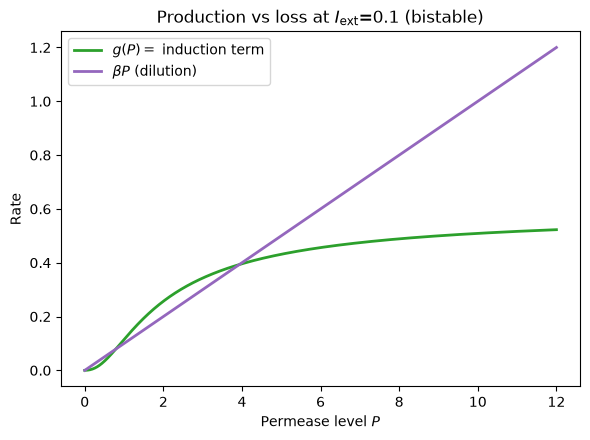

External TMG = 0.1 : three intersections are visible above → 3 fixed points.


In [1]:
# %matplotlib inline  # (optional in Jupyter)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---- Model parameters (dimensionless) ----
alpha, beta = 1.0, 0.1        # max synthesis, dilution+degradation
rho, KP, KI, n = 10.0, 1.0, 1.0, 4   # concentration factor, half-sats, Hill coeff

def internal_inducer(P, Iext):
    return Iext * (1.0 + rho * P / (KP + P))

def production(P, Iext):
    Iin = internal_inducer(P, Iext)
    u = (Iin / KI) ** n
    return alpha * u / (1.0 + u)          # Hill/induction function g(P)

def rhs(P, Iext):
    return production(P, Iext) - beta * P # dP/dt

# ---- Nullclines: production curve g(P) vs the linear loss curve beta*P ----
P = np.linspace(0, 12, 800)
Iext_bi = 0.10                            # a concentration INSIDE the bistable window
g = production(P, Iext_bi)
loss = beta * P

fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(P, g, lw=2, color='tab:green', label=r'$g(P)=$ induction term')
ax.plot(P, loss, lw=2, color='tab:purple', label=r'$\beta P$ (dilution)')
ax.set_xlabel(r'Permease level $P$')
ax.set_ylabel('Rate')
ax.set_title(f'Production vs loss at $I_{{\\rm ext}}$={Iext_bi} (bistable)')
ax.legend(); fig.tight_layout(); plt.show()

# Three crossings -> three fixed points (OFF, middle, ON)
print('External TMG =', Iext_bi, ': three intersections are visible above → 3 fixed points.')

## Do the fixed points explain all-or-none and maintenance?

**Yes.** For the one-dimensional ODE $\dot P = g(P) - \beta P$ the fixed points are the intersections
of the sigmoidal production curve $g(P)$ with the straight loss line $\beta P$. The number of
intersections changes with $I_{\rm ext}$:

* **very low $I_{\rm ext}$** → the production curve barely rises → **1 fixed point** (low, OFF): cells
  stay uninduced;
* **intermediate $I_{\rm ext}$** (the *bistable window*) → the S-shaped curve crosses the loss line
  **3 times** → **two stable** fixed points (OFF $P_-$, ON $P_+$) and **one unstable** one ($P_0$ in
  between);
* **high $I_{\rm ext}$** → production rises steeply at small $P$ → **1 fixed point** (high, ON): all
  cells induce.

**Stability test (1-D):** a fixed point $P^*$ is *locally stable* when the rate of change decreases
through $P^*$, i.e. $f'(P^*)<0$; it is *unstable* when $f'(P^*)>0$. Because the middle fixed point
sits on the *rising* part of the S curve (where $g'(P)>\beta$), **it is always the unstable one**;
the two extremes sit on the *falling* parts ($g'(P)<\beta$) and are **stable**. Geometrically the middle
intersection is the *unstable barrier* separating the two stable basins — the mathematical origin of
the **all-or-none** character of induction.

**Why the middle (unstable) state is never seen:** any perturbation, however small, pushes $P$ towards
one of the two stable points → cells are *either* OFF *or* ON, never halfway. This is precisely the
all-or-none observation.


In [2]:
# Numerically find the fixed points and their stability (derivative test)
def find_fixed_points(Iext, Pmax=12, N=8000):
    Pgrid = np.linspace(0, Pmax, N)
    val = rhs(Pgrid, Iext)
    s = np.sign(val)
    idx = np.where(np.diff(s) != 0)[0]
    roots = []
    for j in idx:
        a, b = Pgrid[j], Pgrid[j+1]
        for _ in range(60):
            m = (a + b) / 2
            if np.sign(rhs(a, Iext)) != np.sign(rhs(m, Iext)):
                b = m
            else:
                a = m
        roots.append((a + b) / 2)
    return roots

def stability(Pstar, Iext, eps=1e-6):
    dfdp = (rhs(Pstar + eps, Iext) - rhs(Pstar - eps, Iext)) / (2 * eps)
    return dfdp, ('STABLE' if dfdp < 0 else 'UNSTABLE')

print(f"{'I_ext':>7} | {'#FP':>3} | fixed points  P*  (with stability)")
print('-'*60)
for Iext in [0.03, 0.06, 0.0925, 0.10, 0.13, 0.16, 0.19, 0.23]:
    fps = find_fixed_points(Iext)
    info = []
    for r in fps:
        d, st = stability(r, Iext)
        info.append(f"{r:.3f}({st[0]})")
    print(f"{Iext:7.3f} | {len(fps):3d} | " + ", ".join(info))

# The bistable window (from numerical fold scan)
print()
print("At I_ext = 0.10 (inside the bistable window):")
for r in find_fixed_points(0.10):
    d, st = stability(r, 0.10)
    print(f"   P* = {r:8.4f}   f'(P*) = {d:+.4f}  -> {st}")

  I_ext | #FP | fixed points  P*  (with stability)
------------------------------------------------------------
  0.030 |   1 | 0.000(S)
  0.060 |   1 | 0.000(S)
  0.092 |   3 | 0.001(S), 1.532(U), 2.179(S)
  0.100 |   3 | 0.001(S), 0.789(U), 3.933(S)
  0.130 |   3 | 0.003(S), 0.274(U), 7.237(S)
  0.160 |   3 | 0.009(S), 0.121(U), 8.660(S)
  0.190 |   1 | 9.295(S)
  0.230 |   1 | 9.663(S)

At I_ext = 0.10 (inside the bistable window):
   P* =   0.0010   f'(P*) = -0.0959  -> STABLE
   P* =   0.7887   f'(P*) = +0.0679  -> UNSTABLE
   P* =   3.9327   f'(P*) = -0.0563  -> STABLE


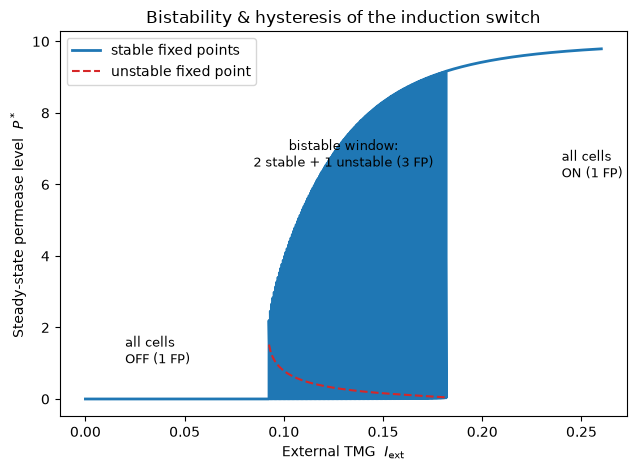

Bistable window found by fold scan: see where the number of fixed points jumps 1 -> 3 -> 1.


In [3]:
# Bifurcation diagram: fixed points vs external TMG  (the hysteresis "S" curve)
Iexts = np.linspace(0, 0.26, 400)
I_stab, P_stab, I_unst, P_unst = [], [], [], []
for Ie in Iexts:
    for r in find_fixed_points(Ie):
        d, st = stability(r, Ie)
        if st == 'STABLE':
            I_stab.append(Ie); P_stab.append(r)
        else:
            I_unst.append(Ie); P_unst.append(r)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(I_stab, P_stab,   color='tab:blue',  lw=2, label='stable fixed points')
ax.plot(I_unst, P_unst,   color='tab:red',   lw=1.5, ls='--', label='unstable fixed point')
ax.set_xlabel(r'External TMG  $I_{\rm ext}$')
ax.set_ylabel(r'Steady-state permease level  $P^*$')
ax.set_title('Bistability & hysteresis of the induction switch')
ax.annotate('all cells\nOFF (1 FP)', (0.02, 1.0), fontsize=9)
ax.annotate('all cells\nON (1 FP)', (0.24, 6.2), fontsize=9)
ax.annotate('bistable window:\n2 stable + 1 unstable (3 FP)', (0.13, 6.5), fontsize=9,
            ha='center', color='black')
ax.legend(loc='upper left'); fig.tight_layout(); plt.show()

print('Bistable window found by fold scan: see where the number of fixed points jumps 1 -> 3 -> 1.')

## Parameter scan: is the switch robust as other parameters change?

So far $I_{\rm ext}$ was our only *control* (bifurcation) parameter. But whether a **bistable window**
exists at all depends on the *shape* of the production curve $g(P)$, i.e. on other model parameters.
Three are most instructive:

* **Hill coefficient $n$** (cooperativity of induction). The S-shape of $g(P)$ requires $n>1$. For
  $n=1$ (Michaelis--Menten-like, no cooperativity) $g(P)$ rises with steadily *decreasing* slope and
  meets the linear loss line $\beta P$ **once** --- no S-curve, no bistability. For larger $n$ the curve
  bends more sharply and the bistable window opens and widens.
* **Concentration factor $\rho$** (how strongly permease concentrates TMG). If $\rho$ is too small,
  $I_{\rm in}\approx I_{\rm ext}$ almost independently of $P$: the feedback loop is effectively broken
  and the cell is never bistable. Bistability appears only above a threshold $\rho^*$.
* **Loss rate $\beta$** (dilution + degradation). Raising $\beta$ steepens the straight line $\beta P$;
  beyond a threshold $\beta^*$ it cuts $g(P)$ in only one point --- bistability disappears. This is the
  textbook trade-off: *stronger degradation destabilises the switch*.

Below we fix $I_{\rm ext}=0.10$ (inside the reference bistable window) and sweep each parameter,
counting how many fixed points remain.

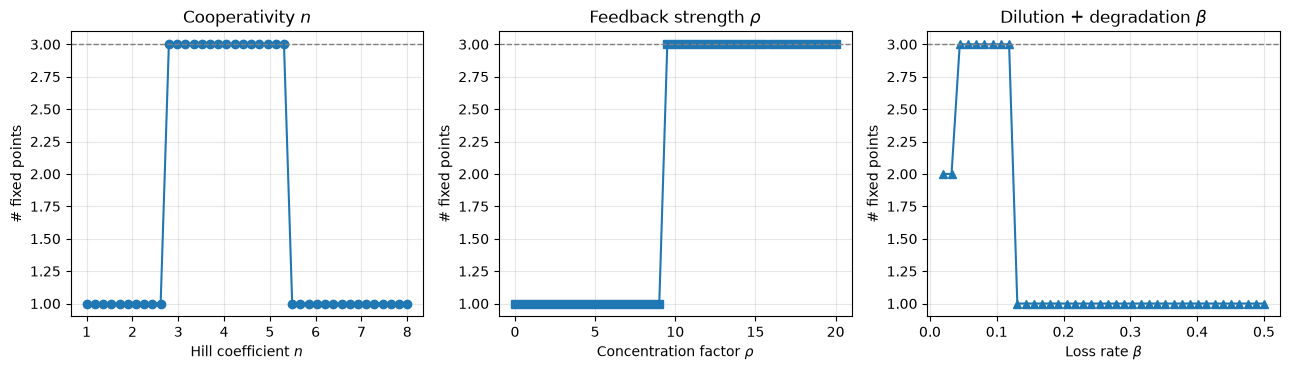

1 point  = monostable (no switch possible)
3 points = bistable (switch possible)
=> Bistability needs n sufficiently >1, rho > rho*, beta < beta*;
   i.e. a steep cooperative response + strong positive feedback + weak dilution.


In [4]:
# ---- Parameter scan: # of fixed points vs n, rho, beta  (I_ext fixed) ----
def mk_p(n, rho, beta, alpha=1.0, KP=1.0, KI=1.0):
    def prod(P, Iext):
        Iin = Iext * (1.0 + rho*P/(KP+P))
        u = (Iin/KI)**n
        return alpha*u/(1.0+u)
    return prod, beta

def n_fixed(prod, beta, Iext, Pmax=12.0, N=8000):
    Pg = np.linspace(0, Pmax, N)
    val = prod(Pg, Iext) - beta*Pg
    return len(np.where(np.diff(np.sign(val)) != 0)[0])

def scan(param, vals):
    out = []
    for v in vals:
        if   param=='n':    pr, b = mk_p(n=v,     rho=10.0, beta=0.1)
        elif param=='rho':  pr, b = mk_p(n=4,     rho=v,    beta=0.1)
        elif param=='beta': pr, b = mk_p(n=4,     rho=10.0, beta=v)
        out.append(n_fixed(pr, b, 0.10))
    return np.array(out)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

nv = np.linspace(1.0, 8.0, 40)
axes[0].plot(nv, scan('n', nv), 'o-')
axes[0].axhline(3, color='gray', ls='--', lw=1)
axes[0].set_xlabel(r'Hill coefficient $n$')
axes[0].set_ylabel('# fixed points')
axes[0].set_title('Cooperativity $n$')

rv = np.linspace(0.0, 20.0, 41)
axes[1].plot(rv, scan('rho', rv), 's-')
axes[1].axhline(3, color='gray', ls='--', lw=1)
axes[1].set_xlabel(r'Concentration factor $\rho$')
axes[1].set_ylabel('# fixed points')
axes[1].set_title(r'Feedback strength $\rho$')

bv = np.linspace(0.02, 0.5, 40)
axes[2].plot(bv, scan('beta', bv), '^-')
axes[2].axhline(3, color='gray', ls='--', lw=1)
axes[2].set_xlabel(r'Loss rate $\beta$')
axes[2].set_ylabel('# fixed points')
axes[2].set_title(r'Dilution + degradation $\beta$')

for ax in axes: ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print('1 point  = monostable (no switch possible)')
print('3 points = bistable (switch possible)')
print('=> Bistability needs n sufficiently >1, rho > rho*, beta < beta*;')
print('   i.e. a steep cooperative response + strong positive feedback + weak dilution.')

## Reading the S-curve: all-or-none, maintenance, and why TMG changes enzyme growth

* **All-or-none**: inside the bistable window an individual cell lives at one of the *two solid*
  (stable) branches. The dashed middle branch is the **unstable** separator; a cell can never *remain*
  there. This is why a low-TMG population is a mixture of OFF and ON cells, never intermediates.

* **The maintenance concentration = hysteresis.** Follow the S-curve from high $I_{\rm ext}$ and decrease
  it: a cell that has *been* ON stays on the **upper stable branch** and remains fully induced even at
  low TMG (the *maintenance* state). Now start from low TMG and a naive (OFF) cell: it stays on the
  **lower stable branch** and never induces. At the *same* low $I_{\rm ext}$, **two different outcomes
  are stable depending on history** — that is hysteresis, the mathematical essence of what Novick & Weiner
  called the maintenance concentration.

* **Why higher external TMG gives more/faster enzyme activity.** As $I_{\rm ext}$ grows, the stable ON
  branch *and* the bistable window expand; more cells fall onto the upper branch. Equivalently the
  *barrier* (distance from OFF to the unstable point) shrinks, so a naive cell is more likely to be
  "pushed over" into the induced state. Hence the fraction of induced cells (and therefore the *measured*
  enzyme activity of the culture) rises with TMG — their Table 1 *intermediate saturation* values.


---

# Part II — The stochastic picture (Module 2)

The deterministic fixed-point analysis explains *why the two stable states exist and are maintained*,
but it **cannot** say how a cell ever gets *from* OFF *to* ON in the first place — in the ODE the OFF
state is perfectly stable and a naive cell would sit there forever. The only way to cross the unstable
barrier is **noise**: random molecular fluctuations. This is exactly Novick & Weiner's "single random
event" — the appearance of the first permease molecule.

So we now move to **Module 2** and simulate the *same* positive-feedback loop stochastically in two ways:

1. **A population of discrete cells** (rule-based, the style used in the course's stochastic notebook),
   where each cell flips stochastically; we count **how many cells are induced** → reproduces intermediate
   saturation *and* the maintenance effect as an emergent population property.
2. **A single-cell Continuous-time / Gillespie-type master equation**, the rigorous Module-2 treatment,
   which shows single cells sit in one of the two basins and jump between them by noise.

The stochastic model is deliberately kept as the same physical loop as Part I (permease concentrates the
inducer; induced permease made faster above a threshold) but with random, indivisible events.


In [5]:
# Stochastic Model A — population of cells (vectorised for speed)
rng = np.random.default_rng(0)

def pop_switch(n_cells, Iext, max_time, seed=0, preinduced=False):
    '''
    Rule-based stochastic switch (lac/permease positive feedback), peer-cell style.

    Each cell: P = permease molecules, I = internal inducer molecules.
      - basal permease production : small (repressed state)
      - permease degradation      : small
      - inducer uptake            : grows with external TMG AND with P  (the feedback)
      - inducer leak              : P-independent exit
      - all-or-none switch        : if internal inducer > 3, boost permease strongly
    Returns times, fraction-induced, and final permease array.
    '''
    rng = np.random.default_rng(seed)
    P = np.zeros(n_cells, dtype=int)
    I = np.zeros(n_cells, dtype=int)
    if preinduced:
        P[:] = 8; I[:] = 6            # start every cell fully ON
    frac, tpts = [], []
    for t in range(max_time):
        # basal production / degradation of permease
        P += (rng.random(n_cells) < 0.01).astype(int)
        m = (rng.random(n_cells) < 0.02) & (P > 0); P[m] -= 1
        # inducer uptake: external TMG drives flux, permease concentrates it (feedback)
        up = Iext * (0.03 + 0.12 * P / (1 + P))
        I += (rng.random(n_cells) < up).astype(int)
        m = (rng.random(n_cells) < 0.10) & (I > 0); I[m] -= 1
        # all-or-none switch
        m = (I > 3) & (rng.random(n_cells) < 0.30); P[m] += 2
        if t % 5 == 0:
            frac.append(np.mean(P > 5)); tpts.append(t)
    return np.array(tpts), np.array(frac), P

# quick sanity run
t, fr, P = pop_switch(600, Iext=3.0, max_time=250, seed=1)
print('example: n_cells=600, I_ext=3 -> fraction induced = %.3f' % fr[-1])

example: n_cells=600, I_ext=3 -> fraction induced = 0.962


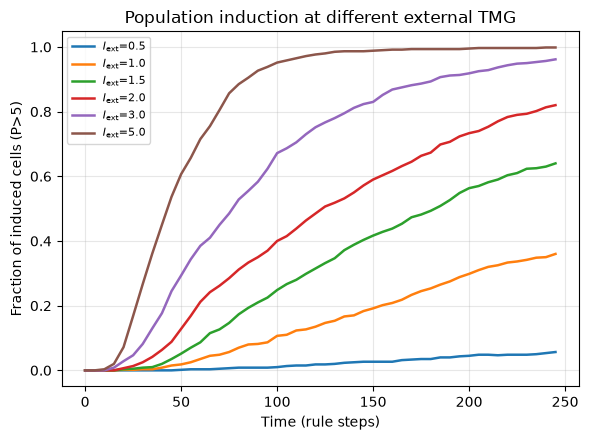

In [6]:
# (i) Fraction induced over time for several external TMG concentrations (naive cells)
tmax = 250; ncells = 600
Iext_vals = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
fig, ax = plt.subplots(figsize=(6,4.5))
for Ie in Iext_vals:
    t, fr, _ = pop_switch(ncells, Ie, tmax, seed=1)
    ax.plot(t, fr, lw=1.8, label=f'$I_{{\\rm ext}}$={Ie}')
ax.set_xlabel('Time (rule steps)'); ax.set_ylabel('Fraction of induced cells (P>5)')
ax.set_title('Population induction at different external TMG')
ax.legend(fontsize=8); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

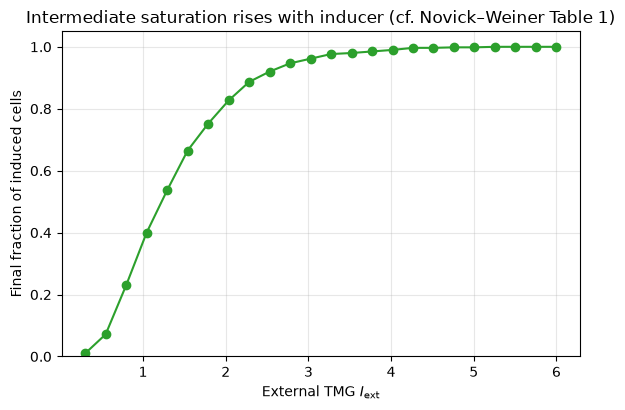

In [7]:
# (ii) Intermediate saturation: final induced fraction vs external TMG  (compare Table 1 of the paper)
Iext_grid = np.linspace(0.3, 6.0, 24)
frac_final = [pop_switch(600, Ie, 250, seed=1)[1][-1] for Ie in Iext_grid]

fig, ax = plt.subplots(figsize=(6,4.2))
ax.plot(Iext_grid, frac_final, 'o-', color='tab:green')
ax.set_xlabel(r'External TMG $I_{\rm ext}$')
ax.set_ylabel('Final fraction of induced cells')
ax.set_title('Intermediate saturation rises with inducer (cf. Novick–Weiner Table 1)')
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

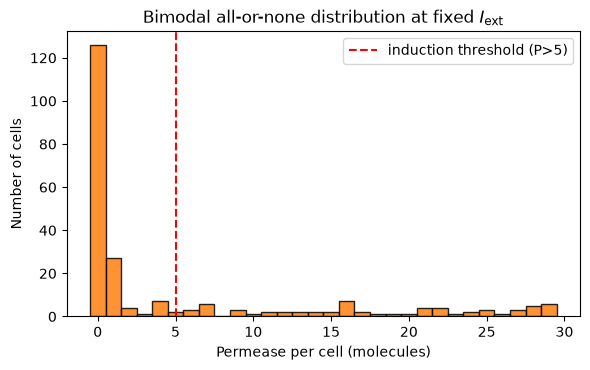

In [8]:
# (iii) All-or-none: bimodal distribution of permease across cells at a bistable TMG
_, _, Pfinal = pop_switch(1000, Iext=2.0, max_time=250, seed=1)
fig, ax = plt.subplots(figsize=(6,3.8))
ax.hist(Pfinal, bins=np.arange(-0.5, 30, 1.0), color='tab:orange', edgecolor='black', alpha=0.85)
ax.set_xlabel('Permease per cell (molecules)'); ax.set_ylabel('Number of cells')
ax.set_title('Bimodal all-or-none distribution at fixed $I_{\\rm ext}$')
ax.axvline(5, color='red', ls='--', label='induction threshold (P>5)')
ax.legend(); fig.tight_layout(); plt.show()

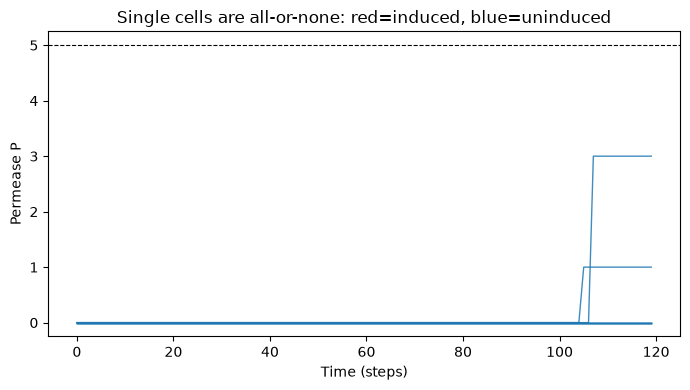

In [9]:
# (iv) Single-cell trajectories: each cell is either OFF (blue) or ON (red) — all-or-none
def single_cell_trace(Iext, T=120, seed=0):
    rng = np.random.default_rng(seed)
    P, I, tr = 0, 0, []
    for _ in range(T):
        P += 1 if rng.random() < 0.01 else 0
        if rng.random() < 0.02 and P > 0: P -= 1
        if rng.random() < Iext*(0.03 + 0.12*P/(1+P)): I += 1
        if rng.random() < 0.10 and I > 0: I -= 1
        if I > 3 and rng.random() < 0.30: P += 2
        tr.append(P)
    return np.array(tr)

fig, ax = plt.subplots(figsize=(7,4))
for k in range(8):
    tr = single_cell_trace(Iext=2.0, seed=100+k)
    col = 'red' if tr[-1] > 5 else 'tab:blue'
    ax.plot(tr, color=col, lw=1, alpha=0.85)
ax.axhline(5, color='black', ls='--', lw=0.8)
ax.set_xlabel('Time (steps)'); ax.set_ylabel('Permease P')
ax.set_title('Single cells are all-or-none: red=induced, blue=uninduced')
fig.tight_layout(); plt.show()

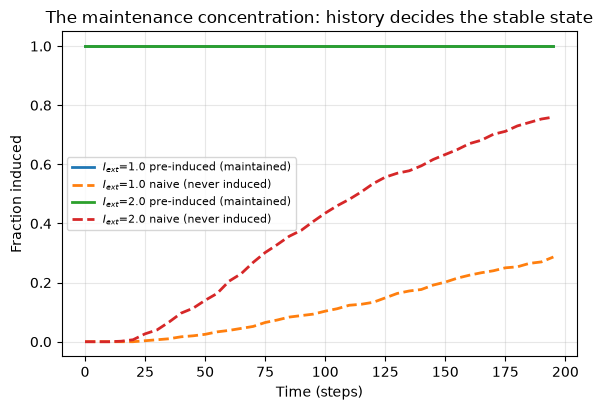

Pre-induced population stays ~100% induced at low TMG;
a naive population at the SAME low TMG essentially never induces -> hysteresis (maintenance).


In [10]:
# (v) MAINTENANCE: same low external TMG, different outcome by history
#
#  - 'pre-induced' cells started fully ON   -> STAY ON (maintained), even at low TMG
#  - 'naive' cells started OFF              -> mostly STAY OFF
tmax = 200; ncells = 600
fig, ax = plt.subplots(figsize=(6,4.2))
for Ie in [1.0, 2.0]:
    _, fr_pre, _ = pop_switch(ncells, Ie, tmax, seed=2, preinduced=True)
    _, fr_naive, _ = pop_switch(ncells, Ie, tmax, seed=3, preinduced=False)
    ax.plot(np.arange(len(fr_pre))*5, fr_pre,  ls='-',  lw=2,
            label=f'$I_{{ext}}$={Ie} pre-induced (maintained)')
    ax.plot(np.arange(len(fr_naive))*5, fr_naive, ls='--', lw=2,
            label=f'$I_{{ext}}$={Ie} naive (never induced)')
ax.set_xlabel('Time (steps)'); ax.set_ylabel('Fraction induced')
ax.set_title('The maintenance concentration: history decides the stable state')
ax.legend(fontsize=8); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

print("Pre-induced population stays ~100% induced at low TMG;\n"
      "a naive population at the SAME low TMG essentially never induces -> hysteresis (maintenance).")

---

## Intermediate saturation: induction rate vs. growth-rate selection

**Table 1** of Novick & Weiner shows that at low TMG the induced fraction rises with TMG but saturates
**below 100%** (e.g. 6.7% → 43% at 7→10 μM). In their model this plateau is a *birth–death balance*
between two opposing forces:

* a **random induction event** at rate $K$: an *uninduced* cell acquires its first permease molecule and
  snaps to ON ($K$ rises with external TMG);
* a **growth-rate penalty**: induced cells grow more slowly than uninduced ($a_1 < a$, the paper estimates
  ~7%/generation), so ON cells are progressively diluted by faster-growing OFF cells.

With $x=$ ON cells, $y=$ OFF cells ($\dot x = a_1 x + K y$, $\dot y = a y - K y$), the self-similar
(balanced-growth) solution gives a stable induced fraction
$$
f^* = \frac{x}{x+y} = \min\Big(1,\; \frac{K}{a - a_1}\Big),
$$
so the plateau rises with $K$ (induction strength / TMG) and falls as the growth penalty
$s = a - a_1$ grows. When $K$ becomes negligible (transfer to a *maintenance* concentration, almost no new
induction), $f^* \to 0$ and a *partially* induced culture instead loses its ON fraction at ~$s$ per
generation — the ~7%/generation exponential fall reported in the paper. Which plateau you see depends on history, exactly as in the maintenance experiment: a **naive**
(uninduced) culture rises toward the intermediate plateau $f^*<1$; a culture that is already **fully
induced** stays pinned near 100% (the maintenance state) because it has no uninduced cells left to drain
its ON fraction. The discrete fixed point of the iteration below is $f^*=\min\big(1,\ \tfrac{K(1-s)}{(1-K)s}\big)$,
which reduces to $K/(a-a_1)$ in the continuous (small-$K$) limit.

The birth–death picture also
makes clear why Module 2's randomness matters: the influx $K$ is driven by single random first-permease
events, and the population-level balance is its deterministic average.


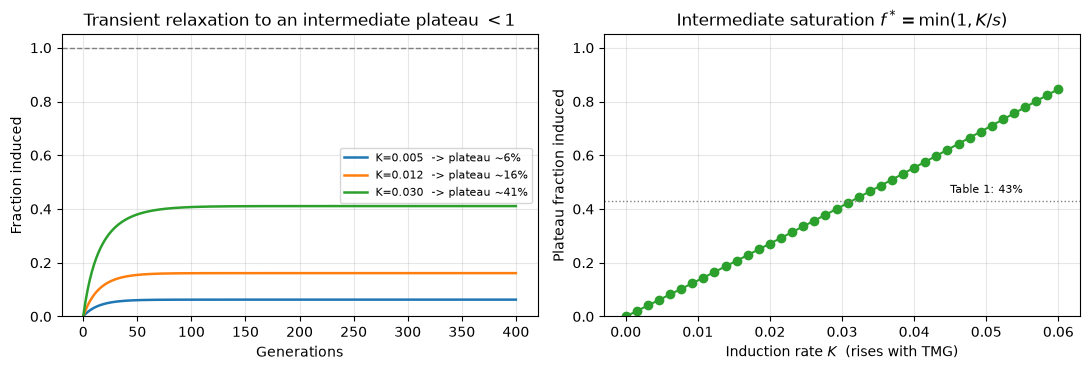

K=0.0047  continuous f*=  6.7% | exact discrete=  6.3% | simulated=  6.3%
K=0.0120  continuous f*= 17.1% | exact discrete= 16.1% | simulated= 16.1%
K=0.0300  continuous f*= 42.9% | exact discrete= 41.1% | simulated= 41.1%
At maintenance (K=0) a partially-induced culture falls exponentially:
  after 1 gen: 0.482   after 10 gen: 0.326
  per-generation factor 0.894  (~10.6% loss/gen)


In [11]:
# ---- Intermediate saturation: induction-vs-selection birth–death balance ----
#   ON fraction p. Each generation:
#     * induction: a fraction K of OFF cells get their first permease and snap ON  (random event;
#       K == strength of induction; rises with external TMG)
#     * growth selection: ON cells divide with a penalty s vs OFF cells (s = a - a1 > 0)
#   Self-similar balance gives the stable plateau f* = min(1, K/s).
def pop_paper(p0, K, s, gens=400):
    p = p0; hist = [p]
    for _ in range(gens):
        off, on = 1 - p, p
        newly = K * off                # random induction of OFF cells (first permease molecule)
        on2, off2 = on + newly, off - newly
        w_on  = on2 * (1 - s)          # ON grows slower than OFF
        w_off = off2
        p = w_on / (w_on + w_off)
        hist.append(p)
    return np.array(hist)

s = 0.07                               # ~7%/generation growth penalty of induced cells (paper)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# (a) transient -> plateau for several induction rates K (K rises with TMG)
for K in [0.0047, 0.012, 0.030]:
    h = pop_paper(0.001, K, s)
    axes[0].plot(h, lw=1.8, label=f'K={K:.3f}  -> plateau ~{h[-1]*100:.0f}%')
axes[0].axhline(1.0, color='gray', ls='--', lw=1)
axes[0].set_xlabel('Generations'); axes[0].set_ylabel('Fraction induced')
axes[0].set_title('Transient relaxation to an intermediate plateau $<1$')
axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# (b) plateau vs induction rate K  (K rises with TMG)  cf. Table 1
Ks = np.linspace(0.0, 0.06, 40)
plat = [pop_paper(0.001, K, s)[-1] for K in Ks]
axes[1].plot(Ks, plat, 'o-', color='tab:green')
axes[1].axhline(0.43, color='gray', ls=':', lw=1)
axes[1].text(0.045, 0.46, 'Table 1: 43%', fontsize=8)
axes[1].set_xlabel(r'Induction rate $K$  (rises with TMG)')
axes[1].set_ylabel('Plateau fraction induced')
axes[1].set_title(r'Intermediate saturation $f^*=\min(1,K/s)$')
axes[1].set_ylim(0, 1.05); axes[1].grid(alpha=0.3)

fig.tight_layout(); plt.show()

# verify the continuous plateau min(1, K/s) and the exact discrete fixed point vs the simulation
for K in [0.0047, 0.012, 0.030]:
    cont  = min(1.0, K / s)
    exact = min(1.0, K * (1 - s) / ((1 - K) * s))
    num   = pop_paper(0.001, K, s)[-1]
    print(f'K={K:<6.4f}  continuous f*={cont*100:5.1f}% | exact discrete={exact*100:5.1f}% | simulated={num*100:5.1f}%')

# (c) the 7%/generation fall at maintenance (K ~ 0): ON fraction lost to faster OFF growth
h = pop_paper(0.5, 0.0, s, gens=60)             # partially induced culture shifted to K=0
print('At maintenance (K=0) a partially-induced culture falls exponentially:')
print('  after 1 gen: %.3f   after 10 gen: %.3f' % (h[1], h[10]))
print('  per-generation factor %.3f  (~%.1f%% loss/gen)' % (h[10] ** 0.1, (1 - h[10] ** 0.1) * 100))


---

# Stochastic Model B — a single-cell continuous-time (Gillespie) treatment

Module 2's rigorous tool is the **Chemical Master Equation / Gillespie stochastic simulation**.
For one cell we coarse-grain the loop into a continuous-time *birth–death* process on the permease
molecule number $X$ (concentration $p=X/\Omega$, with a system size $\Omega$ that fixes molecule counts):

* **production**: $X \to X+1$ with propensity $a_1(X)=\Omega\,g(X/\Omega,\,I_{\rm ext})$ (the same Hill
  term as Part I, now random and countable);
* **decay/dilution**: $X \to X-1$ with propensity $a_2(X)=\beta X$.

In the mean-field (large-$\Omega$) limit the ensemble average obeys our deterministic ODE again. But for
*finite* molecule numbers, individual cells fluctuate and *jump* across the unstable barrier. Two
independent single cells started in opposite basins remain there for long times (maintenance), but
noise occasionally switches them.

(Gillespie exact SSA: draw the time-to-next event $\tau$ from an exponential with rate
$a_0=a_1+a_2$, then pick the reaction with probabilities $a_1/a_0$, $a_2/a_0$.)


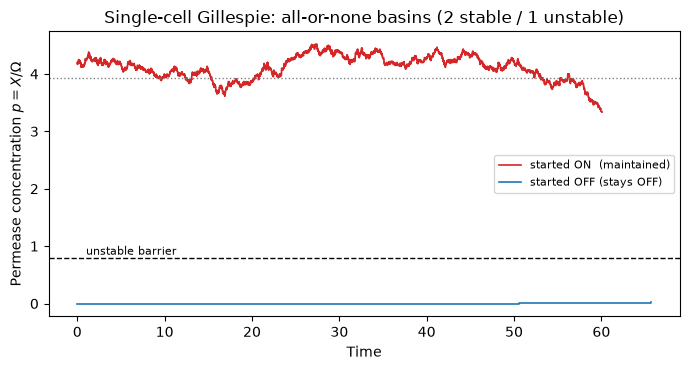

Mean permease (ON-started cells, final): 200.0 molecules  (deterministic ON FP ~ 236)


In [12]:
# Single-cell Gillespie (exact SSA) of the positive-feedback birth-death process
def gillespie_ssa(Iext, Omega, tmax, P0_conc, seed=0):
    rng = np.random.default_rng(seed)
    X = int(P0_conc * Omega)          # start concentration -> molecule number
    t = 0.0; ts = [0.0]; Xs = [X]
    while t < tmax:
        a1 = Omega * production(X / Omega, Iext)   # birth (Hill)
        a2 = beta * X                              # death
        a0 = a1 + a2
        if a0 <= 0: break
        dt = -np.log(1 - rng.random()) / a0
        t += dt
        if rng.random() < a1 / a0: X += 1
        else: X -= 1
        if X < 0: X = 0
        ts.append(t); Xs.append(X)
    return np.array(ts), np.array(Xs)

Omega = 60            # ON state ~ 4.0*60 ~ 240 molecules; OFF ~ 0-1 molecules
Iext = 0.10           # inside the deterministic bistable window
t0, X0 = gillespie_ssa(Iext, Omega, tmax=60, P0_conc=4.2, seed=1)   # started ON
t1, X1 = gillespie_ssa(Iext, Omega, tmax=60, P0_conc=0.0, seed=2)   # started OFF

fig, ax = plt.subplots(figsize=(7,3.8))
ax.step(t0, X0/Omega, where='post', color='tab:red',  lw=1.2, label='started ON  (maintained)')
ax.step(t1, X1/Omega, where='post', color='tab:blue', lw=1.2, label='started OFF (stays OFF)')
ax.axhline(3.93, color='gray', ls=':', lw=1)   # deterministic stable ON
ax.axhline(0.789, color='k', ls='--', lw=1)
ax.text(1, 0.85, 'unstable barrier', fontsize=8)
ax.set_xlabel('Time'); ax.set_ylabel(r'Permease concentration $p=X/\Omega$')
ax.set_title('Single-cell Gillespie: all-or-none basins (2 stable / 1 unstable)')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

# Ensemble average should track the deterministic ON steady state
print('Mean permease (ON-started cells, final): %.1f molecules  (deterministic ON FP ~ %.0f)'
      % (X0[-1], 3.93*Omega))

---

# Part III — Discussion

## Summary of answers to the core questions

**1. "Is the all-or-none phenomenon related to the fixed points of an ODE?" — Yes, directly.**
The positive-feedback loop ($\dot P = g(P) - \beta P$) has a sigmoidal production term whose crossings
with the linear loss line are the steady states.

**2. "How many fixed points, stable or unstable?"**
* Very low $I_{\rm ext}$: **1** stable fixed point (cells OFF).
* Intermediate $I_{\rm ext}$ (the **bistable window**): **3** fixed points — **2 stable** (OFF $P_-$,
  ON $P_+$) and **1 unstable** (middle $P_0$, the separator / barrier).
* High $I_{\rm ext}$: **1** stable fixed point (cells ON).

**3. "Why do different external TMG concentrations give different enzyme-induction behaviour?"**
Because $I_{\rm ext}$ is a *bifurcation parameter*: it steers the system through the 1 → 3 → 1 sequence.
Inside the bistable window the outcome is **history-dependent (hysteresis)** — the **maintenance
concentration**. Higher TMG shrinks the OFF → ON barrier and widens the ON basin, so a larger fraction of
the population is induced (their **intermediate saturation**, Table 1) and enzyme activity grows faster.

**4. "Is this already Module 2 (stochastic)?" — Yes, this is a Module 2 problem.**
The deterministic part is only the *mean-field* backbone. The determination of *which* of the two stable
states a cell actually sits in, and the *transition* between them, is governed by noise:
* the **first permease molecule** is a rare random event (Novick–Weiner's "single random event");
* single cells are **all-or-none**, never intermediate — the unstable fixed point is never occupied;
* the **maintenance** state is a noisy-stability/hysteresis effect: the induced basin is deep enough
  that fluctuations almost never dump a cell out over ~180 generations.

This is precisely the CME / Gillespie material of Module 2, which follows the deterministic fixed-point
analysis we built in Part I.

## Robustness (parameter dependence)

The switch is generic for positive-feedback systems, **not** a special point. As the parameter scan shows,
bistability exists over a wide parameter range, but only when the production response is sufficiently
**cooperative** (Hill $n$ well above 1), the **positive feedback** is strong enough ($\rho$ above $\rho^*$),
and **loss** is weak enough ($\beta$ below $\beta^*$). Vary any of these beyond its threshold and the
S-shaped production curve no longer crosses the loss line three times — the system returns to a single
stable point and loses all-or-none induction. So the numbers chosen above are meaningful, not arbitrary,
and the qualitative phenomenology (all-or-none, maintenance, intermediate saturation) survives as long as
these three conditions hold.

## Relations to Novick & Weiner (1957), point by point

| Observation in the paper | Model reproduction |
|---|---|
| All-or-none single-cell behaviour | Bimodal distribution; middle (unstable) FP never occupied |
| First permease molecule = critical random event | OFF→ON is noise (random) crossing of the unstable barrier |
| Maintenance concentration (pre-induced stays on) | Hysteresis: two stable FPs, history selects the basin |
| Intermediate saturation rises with TMG (Table 1) | Birth–death balance (induction rate $K$ vs growth penalty $s$): plateau $f^*=\min(1,K/s)$ |
| Induced cells grow slower — selection/saturation | Growth penalty $s\approx7\%/\mathrm{gen}$ trades off against induction influx $K$ — plateaus as $f^*=\min(1,K/s)$ (and the ~7%/gen fall at maintenance) |

## Assumptions & limitations
* The rule-based population model uses heuristic per-step probabilities; it is stylised, not a
  molecule-exact master equation. The single-cell Gillespie part is exact for its (coarse) reaction
  set, but the true lac network has separate mRNA/protein stages and stochastic *dilution by division*.
* The intermediate-saturation model is a two-population birth–death balance (induction influx $K$ vs
  growth penalty $s\approx7\%/\mathrm{gen}$). It matches the paper's balance equations (their eq. 3/4) and
  reproduces both the plateau $f^*=\min(1,K/s)$ and the ~7%/generation maintenance fall, but it treats
  $K$ as a continuum rate — the discreteness of the first-permease event is kept only in the
  single-cell Gillespie part.
* Hysteresis time scales depend strongly on system size ($\Omega$); real cells sit close to the fold
  where the barrier is shallow and switching is rare but observable — as the paper finds.
